In [ ]:
# Step 1: Load the Dataset
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [ ]:
# Load dataset
file_path = "/content/Quality of Service 5G.csv"
df = pd.read_csv(file_path)

In [ ]:
df.drop(columns=["User_ID","Timestamp"], errors="ignore", inplace=True)


In [ ]:
# Convert numeric columns to proper formats
df["Signal_Strength"] = df["Signal_Strength"].str.replace(" dBm", "").astype(float)
df["Latency"] = df["Latency"].str.replace(" ms", "").astype(float)
df["Required_Bandwidth"] = df["Required_Bandwidth"].str.replace(" Mbps", "").str.replace(" Kbps", "").astype(float)
df["Allocated_Bandwidth"] = df["Allocated_Bandwidth"].str.replace(" Mbps", "").str.replace(" Kbps", "").astype(float)
df["Resource_Allocation"] = df["Resource_Allocation"].str.replace("%", "").astype(float)

In [ ]:
# Encode categorical column (Application_Type)
df["Application_Type"] = df["Application_Type"].astype("category").cat.codes

print("✅ Dataset loaded and preprocessed successfully!")

✅ Dataset loaded and preprocessed successfully!


In [ ]:
# Step 2: Compute Shannon Entropy

def shannon_entropy(data):
    """Computes Shannon entropy for a given feature."""
    value_counts = data.value_counts(normalize=True)  # Compute probabilities
    return stats.entropy(value_counts)  # Compute entropy
# Compute entropy for each column
entropy_scores = df.apply(shannon_entropy)




In [ ]:
# Compute entropy for all numerical columns
entropy_scores = df.apply(shannon_entropy)

# Step 4: Feature Selection (Select High-Entropy Features)
selected_features = entropy_scores[entropy_scores > entropy_scores.median()].index.tolist()

# Display entropy values
print("🔹 Entropy Scores for Each Feature:")
print(entropy_scores)

🔹 Entropy Scores for Each Feature:
Application_Type       2.176683
Signal_Strength        4.328753
Latency                4.061066
Required_Bandwidth     4.803795
Allocated_Bandwidth    4.867689
Resource_Allocation    1.730246
dtype: float64


In [ ]:


# Print selected features
print("\n🚀 Selected High-Entropy Features for Anomaly Detection:")
print(selected_features)



🚀 Selected High-Entropy Features for Anomaly Detection:
['Signal_Strength', 'Required_Bandwidth', 'Allocated_Bandwidth']


# New Section

In [ ]:
#Step 6: Normalize Selected High-Entropy Features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[selected_features])

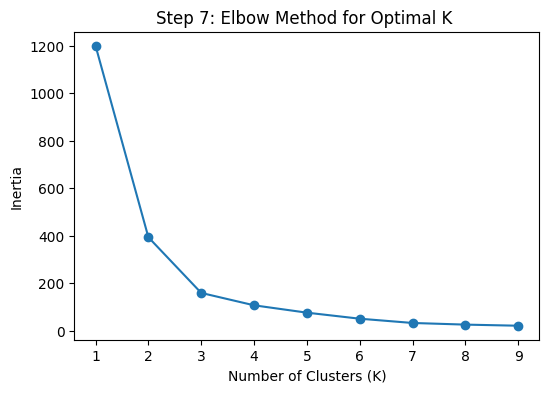

In [ ]:
# Step 7: Find Optimal Number of Clusters Using Elbow Method
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(6, 4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Step 7: Elbow Method for Optimal K ')
plt.show()

In [ ]:
# Test K=3 and K=4 for Silhouette Score
k_values = [3, 4]
silhouette_scores = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_scaled)
    silhouette_avg = silhouette_score(df_scaled, cluster_labels)
    silhouette_scores[k] = silhouette_avg
    print(f"🔹 Silhouette Score for K={k}: {silhouette_avg}")

# Select the best K (higher Silhouette Score is better)
optimal_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\n✅ Optimal number of clusters selected: K={optimal_k}")

🔹 Silhouette Score for K=3: 0.5802655757781772
🔹 Silhouette Score for K=4: 0.5400858912870826

✅ Optimal number of clusters selected: K=3


In [ ]:
# Step 9: Apply K-Means Clustering with Optimal K and Save the Results
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(df_scaled)

# Save the clustered dataset
file_path_output = "/content/Clustered_5G_QoS_Data.csv"
df.to_csv(file_path_output, index=False)

In [ ]:
file_path = "/content/Clustered_5G_QoS_Data.csv"
df_clustered = pd.read_csv(file_path)

In [ ]:
# Step 2: Separate Data into Different Cluster Files
for cluster_num in df_clustered["Cluster"].unique():
    df_cluster = df_clustered[df_clustered["Cluster"] == cluster_num]
    file_name = f"/content/Cluster_{cluster_num}_5G_QoS.csv"
    df_cluster.to_csv(file_name, index=False)
    print(f"✅ Saved Cluster {cluster_num} Data: {file_name}")
    print("\n✅ Cluster separation completed! Each cluster has been saved as a separate file.")


✅ Saved Cluster 0 Data: /content/Cluster_0_5G_QoS.csv

✅ Cluster separation completed! Each cluster has been saved as a separate file.
✅ Saved Cluster 2 Data: /content/Cluster_2_5G_QoS.csv

✅ Cluster separation completed! Each cluster has been saved as a separate file.
✅ Saved Cluster 1 Data: /content/Cluster_1_5G_QoS.csv

✅ Cluster separation completed! Each cluster has been saved as a separate file.


In [ ]:
# Count the number of users in each cluster
cluster_counts = df['Cluster'].value_counts()

# Display the count of users per cluster
print("Number of users in each cluster:")
print(cluster_counts)


Number of users in each cluster:
Cluster
2    200
0    153
1     47
Name: count, dtype: int64


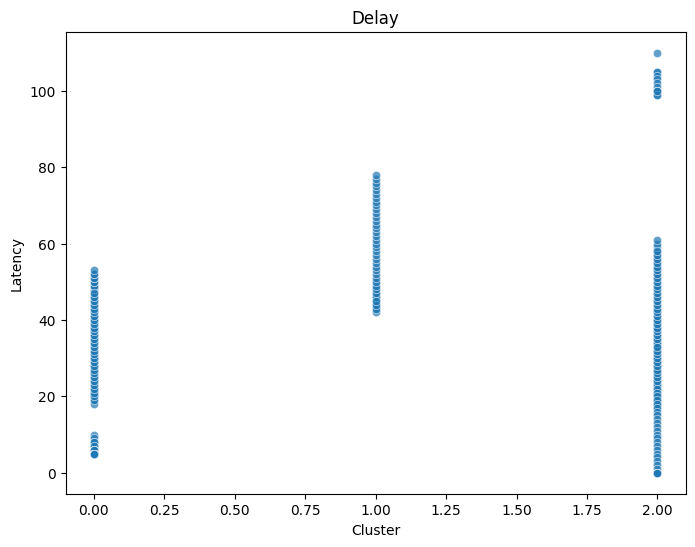

In [ ]:
import seaborn as sns
# Load the main user behavior dataset
user_behavior_file = "/content/Clustered_5G_QoS_Data.csv"  # Update with actual file path
df = pd.read_csv(user_behavior_file)

# 1. Scatter Plot of User Behavior Data
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Cluster'], y=df['Latency'], alpha=0.7)
plt.title("Delay")
plt.xlabel("Cluster")
plt.ylabel("Latency")
plt.show()

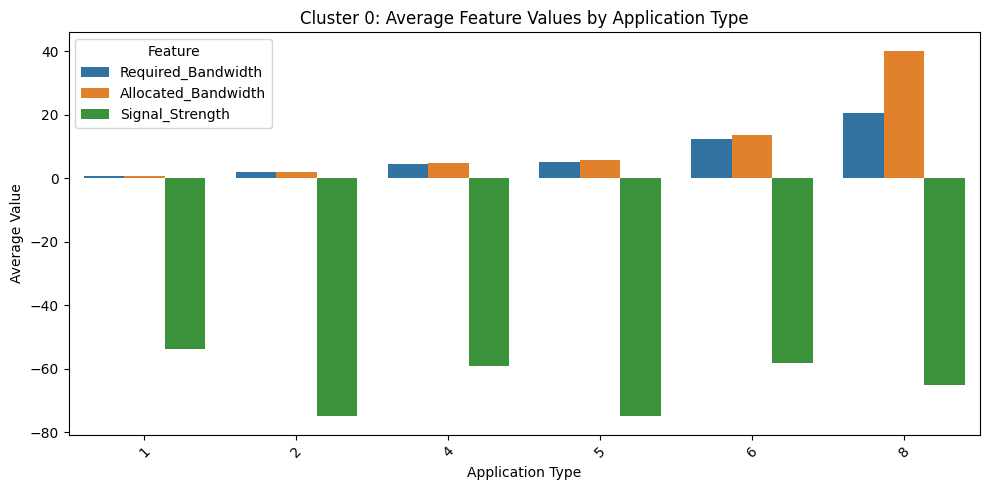

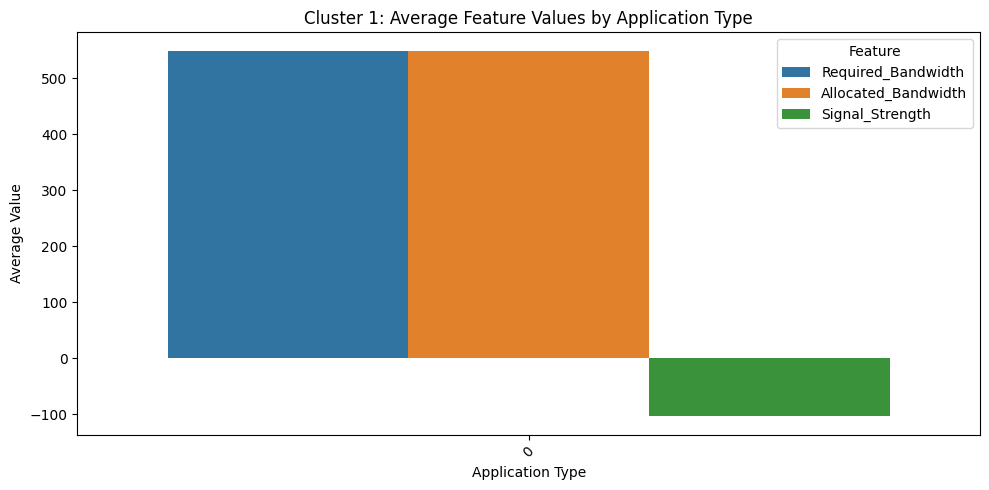

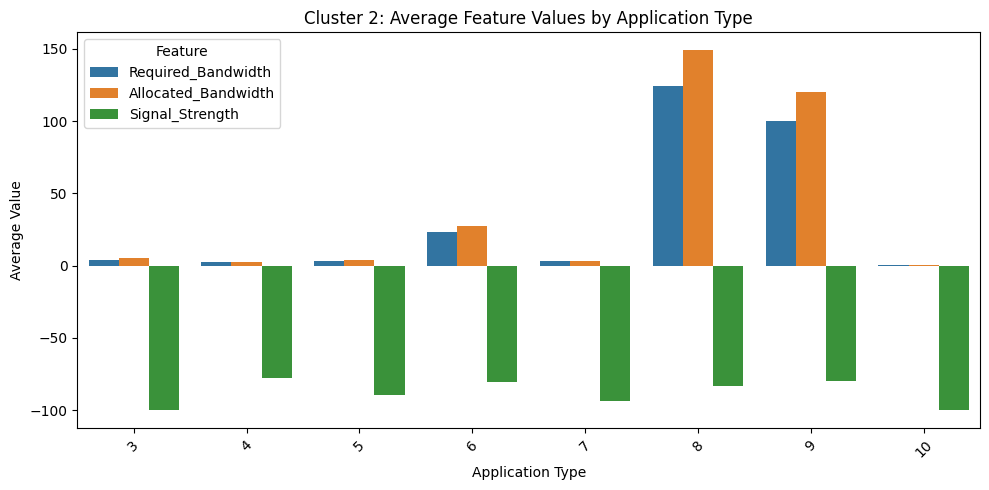

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
user_behavior_file = "/content/Clustered_5G_QoS_Data.csv"
df = pd.read_csv(user_behavior_file)

# Define features of interest
features = ['Required_Bandwidth', 'Allocated_Bandwidth', 'Signal_Strength']

# Loop through each cluster and plot
for cluster_id in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster_id]

    # Group by Application_Type and calculate mean for selected features
    summary = cluster_data.groupby('Application_Type')[features].mean().reset_index()

    # Melt for plotting
    summary_melted = summary.melt(id_vars='Application_Type',
                                   var_name='Feature',
                                   value_name='Average_Value')

    # Plot
    plt.figure(figsize=(10, 5))
    sns.barplot(data=summary_melted, x='Application_Type', y='Average_Value', hue='Feature')
    plt.title(f'Cluster {cluster_id}: Average Feature Values by Application Type')
    plt.xlabel('Application Type')
    plt.ylabel('Average Value')
    plt.xticks(rotation=45)
    plt.legend(title='Feature')
    plt.tight_layout()
    plt.show()


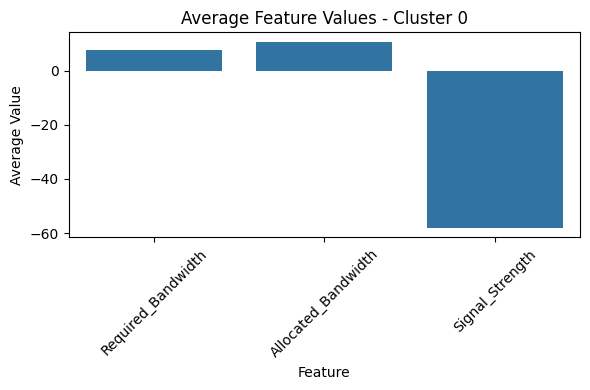

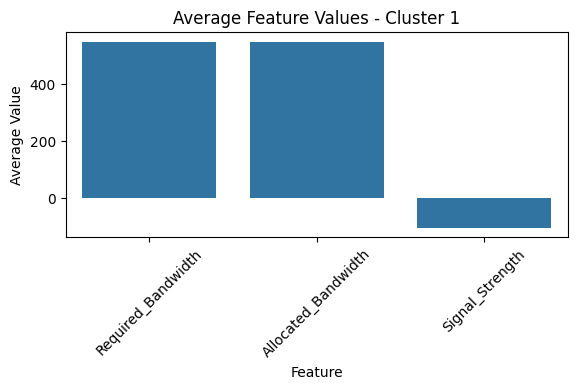

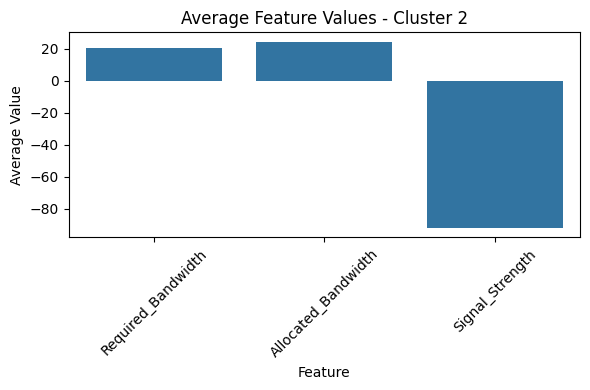

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
user_behavior_file = "/content/Clustered_5G_QoS_Data.csv"
df = pd.read_csv(user_behavior_file)

# Features to plot
features = ['Required_Bandwidth', 'Allocated_Bandwidth', 'Signal_Strength']

# Loop through each cluster
for cluster_id in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster_id]

    # Calculate mean values for the features
    means = cluster_data[features].mean().reset_index()
    means.columns = ['Feature', 'Average_Value']

    # Plot
    plt.figure(figsize=(6, 4))
    sns.barplot(data=means, x='Feature', y='Average_Value')
    plt.title(f'Average Feature Values - Cluster {cluster_id}')
    plt.xlabel('Feature')
    plt.ylabel('Average Value')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


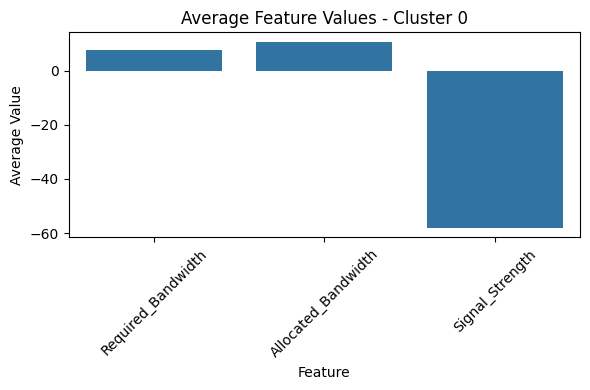

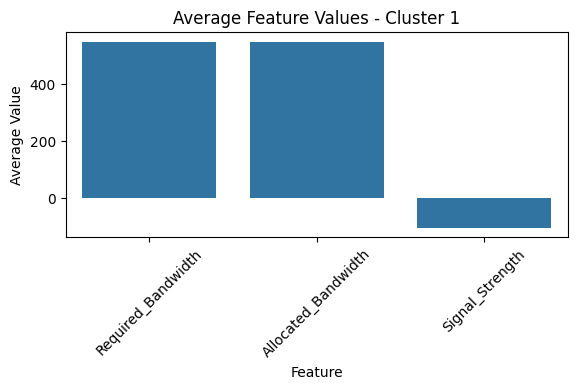

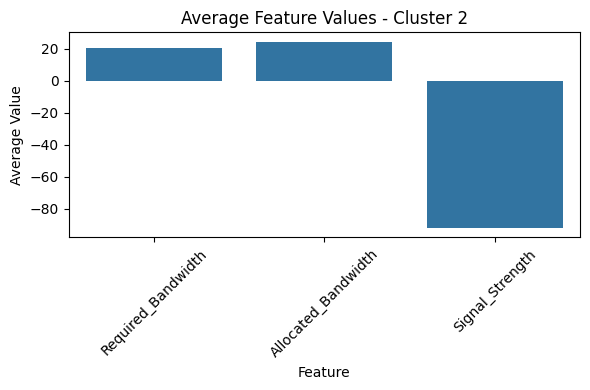

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
user_behavior_file = "/content/Clustered_5G_QoS_Data.csv"
df = pd.read_csv(user_behavior_file)

# Features to plot
features = ['Required_Bandwidth', 'Allocated_Bandwidth', 'Signal_Strength']

# Loop through each cluster
for cluster_id in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster_id]

    # Calculate mean values for the features
    means = cluster_data[features].mean().reset_index()
    means.columns = ['Feature', 'Average_Value']

    # Plot
    plt.figure(figsize=(6, 4))
    sns.barplot(data=means, x='Feature', y='Average_Value')
    plt.title(f'Average Feature Values - Cluster {cluster_id}')
    plt.xlabel('Feature')
    plt.ylabel('Average Value')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Clusters: [0 2 1]


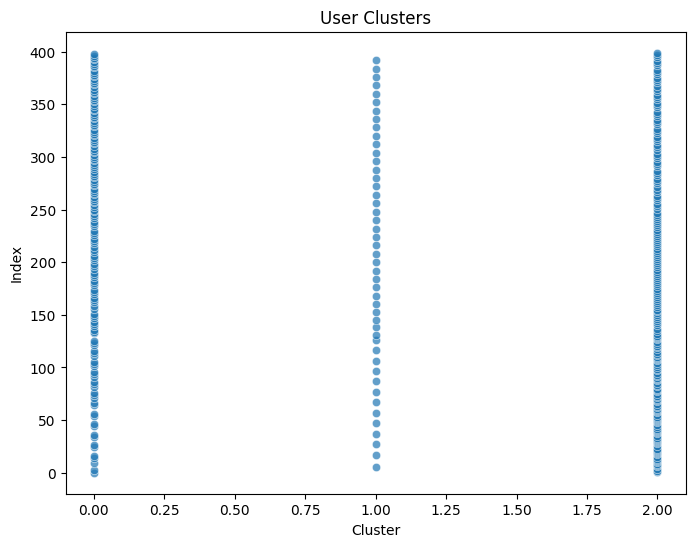

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the main user behavior dataset
user_behavior_file = "/content/Clustered_5G_QoS_Data.csv"  # Update with actual file path
df = pd.read_csv(user_behavior_file)

# Print the unique clusters
print("Clusters:", df['Cluster'].unique())

# Plot with both x and y
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Cluster'], y=df.index, alpha=0.7)
plt.xlabel("Cluster")
plt.ylabel("Index")
plt.title("User Clusters")
plt.show()


Clusters assigned to users: [0 2 1]


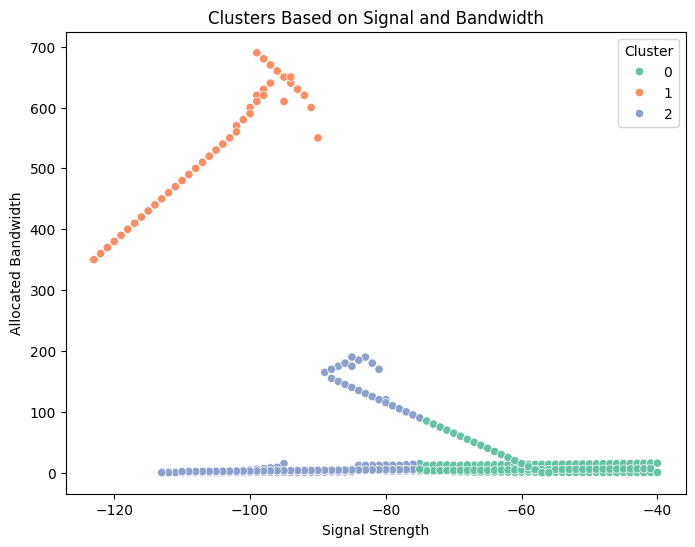

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
user_behavior_file = "/content/Clustered_5G_QoS_Data.csv"  # Update path if needed
df = pd.read_csv(user_behavior_file)

# Features for clustering
features = ['Signal_Strength', 'Required_Bandwidth', 'Allocated_Bandwidth']
X = df[features]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Print cluster labels
print("Clusters assigned to users:", df['Cluster'].unique())

# Visualize clusters in 2D (pick 2 of the 3 features for plotting)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Signal_Strength'], y=df['Allocated_Bandwidth'], hue=df['Cluster'], palette='Set2')
plt.title("Clusters Based on Signal and Bandwidth")
plt.xlabel("Signal Strength")
plt.ylabel("Allocated Bandwidth")
plt.legend(title="Cluster")
plt.show()


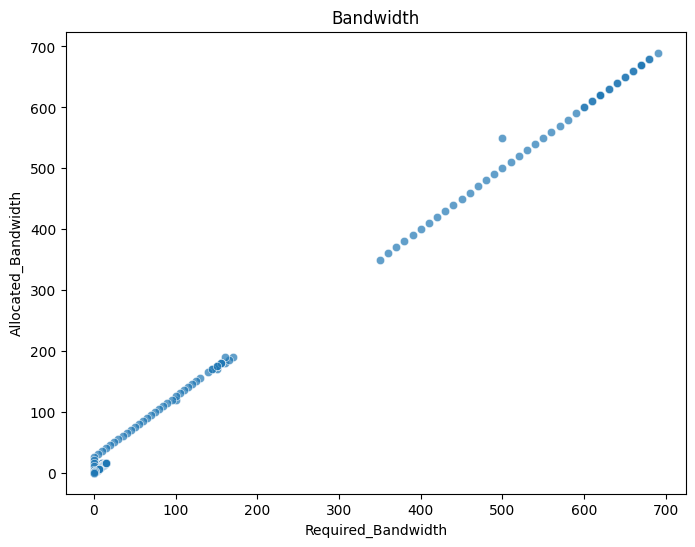

In [ ]:
import seaborn as sns
# Load the main user behavior dataset
user_behavior_file = "/content/Clustered_5G_QoS_Data.csv"  # Update with actual file path
df = pd.read_csv(user_behavior_file)

# 1. Scatter Plot of User Behavior Data
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Required_Bandwidth'], y=df['Allocated_Bandwidth'], alpha=0.7)
plt.title("Bandwidth")
plt.xlabel("Required_Bandwidth")
plt.ylabel("Allocated_Bandwidth")
plt.show()

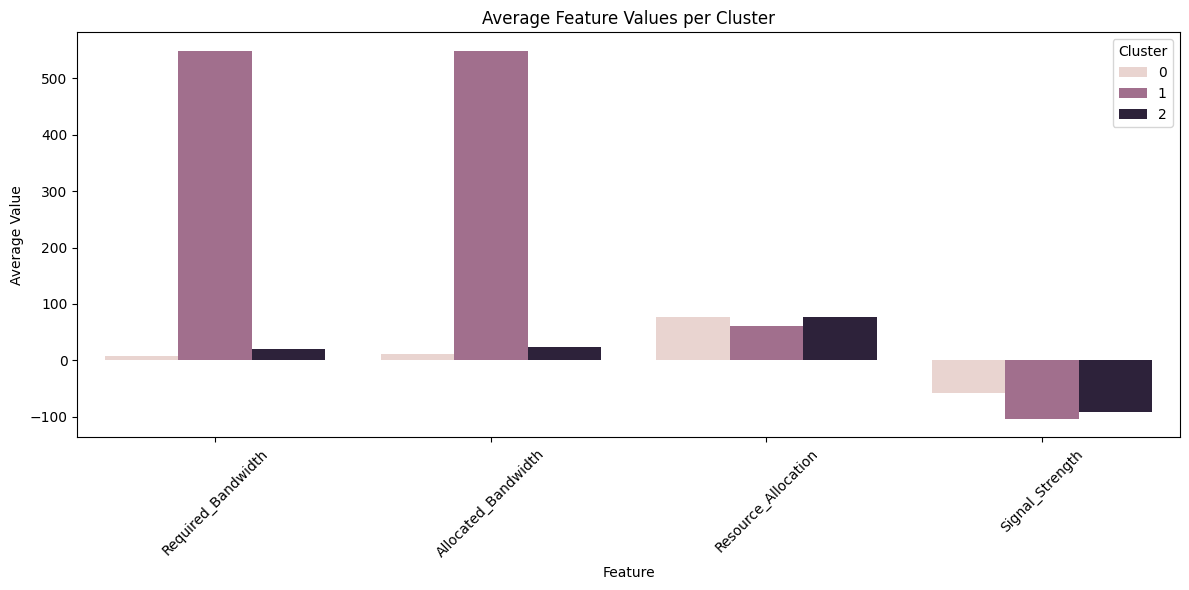

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
user_behavior_file = "/content/Clustered_5G_QoS_Data.csv"
df = pd.read_csv(user_behavior_file)

# Group by cluster and calculate mean of the features
cluster_summary = df.groupby('Cluster')[[
    'Required_Bandwidth',
    'Allocated_Bandwidth',
    'Resource_Allocation',
    'Signal_Strength'
]].mean().reset_index()

# Melt the DataFrame for seaborn compatibility
df_melted = cluster_summary.melt(id_vars='Cluster', var_name='Feature', value_name='Average_Value')

# Create bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Feature', y='Average_Value', hue='Cluster')
plt.title("Average Feature Values per Cluster")
plt.xlabel("Feature")
plt.ylabel("Average Value")
plt.legend(title="Cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<ipython-input-25-48df8fdde1cc>:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(features, rotation=45)
<ipython-input-25-48df8fdde1cc>:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(features, rotation=45)
<ipython-input-25-48df8fdde1cc>:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(features, rotation=45)


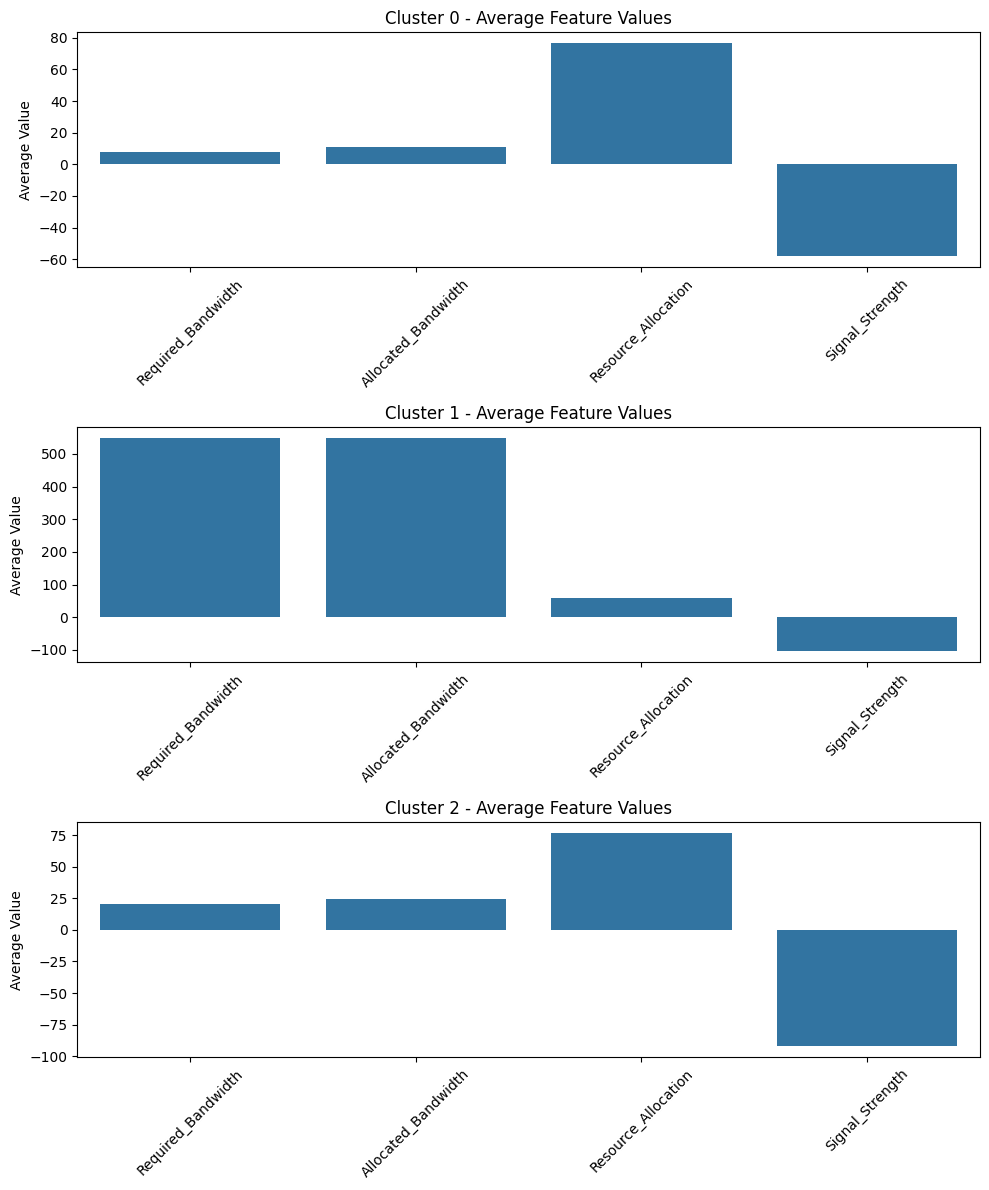

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
user_behavior_file = "/content/Clustered_5G_QoS_Data.csv"
df = pd.read_csv(user_behavior_file)

# Group by cluster and calculate mean
cluster_summary = df.groupby('Cluster')[[
    'Required_Bandwidth',
    'Allocated_Bandwidth',
    'Resource_Allocation',
    'Signal_Strength'
]].mean()

# Plot setup
clusters = cluster_summary.index
features = cluster_summary.columns

fig, axes = plt.subplots(nrows=len(clusters), ncols=1, figsize=(10, 4 * len(clusters)))

# Loop through clusters and plot each one
for i, cluster in enumerate(clusters):
    ax = axes[i]
    sns.barplot(x=features, y=cluster_summary.loc[cluster], ax=ax)
    ax.set_title(f"Cluster {cluster} - Average Feature Values")
    ax.set_ylabel("Average Value")
    ax.set_xlabel("")
    ax.set_xticklabels(features, rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# 2. Load Clustered Data after K-Means Clustering
clustered_file = "Clustered_5G_QoS_Data.csv"  # Update with actual file path
df_clustered = pd.read_csv(clustered_file)

# Define key features based on dataset columns (excluding non-numeric ones)
key_features = [col for col in df_clustered.columns if col not in ["Cluster", "User_ID", "Timestamp"]]

# 3. Compute Z-score for Each Feature
df_clustered[key_features] = df_clustered[key_features].apply(zscore)

# Compute Mean Z-score per Cluster
cluster_z_scores = df_clustered.groupby("Cluster")[key_features].mean()

# Automatically Determine the Z-score Threshold using Standard Deviation
mean_abs_zscore = cluster_z_scores.abs().mean().mean()  # Mean absolute Z-score
std_dev = cluster_z_scores.abs().std().mean()  # Standard deviation of Z-scores
dynamic_threshold = mean_abs_zscore + std_dev  # Simple standard deviation-based threshold

print(f"Dynamic Z-score threshold determined: {dynamic_threshold:.2f}")

def classify_cluster(cluster_id):
    if cluster_id not in cluster_z_scores.index or cluster_z_scores.loc[cluster_id].isnull().all():
        return "Unknown"  # Label empty clusters as Unknown

    cluster_mean_zscore = cluster_z_scores.loc[cluster_id]
    if all(cluster_mean_zscore.abs() < dynamic_threshold):  # If within normal range
        return "Normal"
    else:
        return "Anomalous"

# Assign labels dynamically based on computed Z-score threshold
df_clustered["Ground_Truth_Label"] = df_clustered["Cluster"].apply(classify_cluster)

# Save Cluster Z-score Statistics
ground_truth_stats_file = "cluster_zscore_statistics.csv"
cluster_z_scores.to_csv(ground_truth_stats_file)
print(f"Cluster Z-score statistics saved as {ground_truth_stats_file}")

# Save Z-Scores with Cluster Labels
ground_truth_zscore_file = "z_scores.csv"
df_clustered[['Cluster'] + key_features + ["Ground_Truth_Label"]].to_csv(ground_truth_zscore_file, index=False)
print(f"Z-Scores saved as {ground_truth_zscore_file}")

# 5. Save the Updated Clustered Data with Ground Truth Labels
ground_truth_file = "ground_truth_clusters.csv"
df_clustered.to_csv(ground_truth_file, index=False)

print(f"Ground truth table saved as {ground_truth_file}")


Dynamic Z-score threshold determined: 1.70
Cluster Z-score statistics saved as cluster_zscore_statistics.csv
Z-Scores saved as z_scores.csv
Ground truth table saved as ground_truth_clusters.csv


In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import numpy as np
from sklearn.preprocessing import StandardScaler

# Step 1: Load Clustered Dataset
file_path = "Clustered_5G_QoS_Data.csv"  # Update with correct file path
df = pd.read_csv(file_path)

# Step 2: Define Normal Clusters (0, 2) and Select Features
normal_clusters = [0, 2]
df_normal = df[df["Cluster"].isin(normal_clusters)].copy()
features = ["Signal_Strength", "Required_Bandwidth", "Allocated_Bandwidth"]
train_data = df_normal[features].values

# Step 3: Normalize the Data
scaler = StandardScaler()
train_data_scaled = scaler.fit_transform(train_data)

# Step 4: Define Autoencoder Model
input_dim = train_data_scaled.shape[1]  # Number of features
encoding_dim = 3  # Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# Create Autoencoder Model
autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Step 5: Train Autoencoder on Normal Clusters (0, 2)
autoencoder.fit(train_data_scaled, train_data_scaled, epochs=50, batch_size=16, shuffle=True, verbose=1)

# Step 6: Test Autoencoder on the Entire Dataset
test_data = df[features].values
test_data_scaled = scaler.transform(test_data)

# Compute Reconstruction Error
reconstructed_data = autoencoder.predict(test_data_scaled)
reconstruction_errors = np.mean(np.abs(reconstructed_data - test_data_scaled), axis=1)

# Step 7: Add Anomaly Scores and Define Threshold
df.loc[:, "Reconstruction_Error"] = reconstruction_errors
threshold = np.percentile(reconstruction_errors, 90)  # Adjust threshold based on dataset behavior

# Step 8: Label Anomalies (1 = Abnormal, 0 = Normal)
df.loc[:, "Anomaly"] = (df["Reconstruction_Error"] > threshold).astype(int)

# Step 9: Save Results
file_output = "Autoencoder_Anomaly_Detection.csv"
df.to_csv(file_output, index=False)

print(f"✅ Autoencoder Training and Testing Completed! Results saved to {file_output}")


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2587
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1732 
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2228 
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1439 
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0745 
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0986 
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1599 
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0502 
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9918 
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0136 
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0668 
Epoch 12/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9579 
Epoch 13/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9226 
Epoch 14/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9698 
Epoch 15/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0881 
Epoch

Accuracy: 0.9950
Precision: 1.0000
Recall: 0.8511
F1 Score: 0.9195


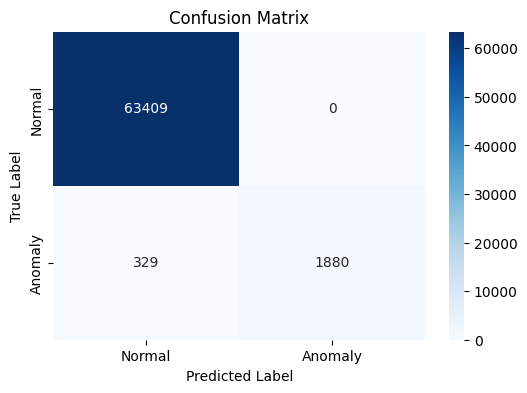

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load Autoencoder Results and Ground Truth Data
file_autoencoder = "Autoencoder_Anomaly_Detection.csv"
file_ground_truth = "ground_truth_clusters.csv"
df_autoencoder = pd.read_csv(file_autoencoder)
df_ground_truth = pd.read_csv(file_ground_truth)

# Merge Data on Cluster
df_combined = df_autoencoder.merge(df_ground_truth, on="Cluster", suffixes=("_autoencoder", "_ground"))

# Map Ground Truth Labels
y_true = df_combined["Ground_Truth_Label"].map({"Normal": 0, "Anomalous": 1})
y_pred = df_combined["Anomaly"]

# Compute Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print Metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plot Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()